# Fine-tuned SimCLRv2 ResNet50 — Paper Figures Notebook

Notebook này là bản sửa của `hiunhooooo.ipynb`.

Mục tiêu:
- Load đúng checkpoint fine-tune `SimCLRFineTuner` (`finetune_resnet50_best.pt`).
- Evaluate lại trên STL-10 test/val split.
- Xuất các hình thực nghiệm tương tự hai notebook báo cáo còn lại: confusion matrix, normalized confusion matrix, per-class accuracy, confidence histogram, confidence theo lớp, summary bar, và optional train/val curves nếu tìm thấy history/log.
- Lưu toàn bộ ảnh vào `paper_outputs/finetune_fixed_eval/figures` và bảng CSV vào `paper_outputs/finetune_fixed_eval/tables`.

> Chạy notebook này ở thư mục project `D:\ML3` hoặc chỉnh `PROJECT_DIR` ở cell Configuration.

In [1]:
from pathlib import Path
import sys, os, re, time, json, math, random
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from IPython.display import display
except Exception:
    display = print

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Configuration

In [2]:
# Auto-detect project root. If this notebook is inside D:\ML3, Path.cwd() usually works.
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "train_resnet.py").exists():
    # Fallback for the original local setup used in the report.
    PROJECT_DIR = Path(r"D:\ML3")

DATA_ROOT = PROJECT_DIR / "data"
CKPT_DIR = PROJECT_DIR / "checkpoints_finetune_2"
CKPT_PATH = CKPT_DIR / "finetune_resnet50_best.pt"  # set to None to auto-pick latest/best .pt

OUT_ROOT = PROJECT_DIR / "paper_outputs" / "finetune_fixed_eval"
FIG_DIR = OUT_ROOT / "figures"
TABLE_DIR = OUT_ROOT / "tables"
CACHE_DIR = OUT_ROOT / "cache"
for d in [OUT_ROOT, FIG_DIR, TABLE_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0  # Windows-friendly. Increase on Linux if needed.
EVAL_BATCH_SIZE = 128
DOWNLOAD_DATA = False
SEED = 42

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_ROOT:", DATA_ROOT)
print("CKPT_DIR:", CKPT_DIR)
print("CKPT_PATH:", CKPT_PATH)
print("OUT_ROOT:", OUT_ROOT)
print("DEVICE:", DEVICE)

PROJECT_DIR: d:\ML3
DATA_ROOT: d:\ML3\data
CKPT_DIR: d:\ML3\checkpoints_finetune_2
CKPT_PATH: d:\ML3\checkpoints_finetune_2\finetune_resnet50_best.pt
OUT_ROOT: d:\ML3\paper_outputs\finetune_fixed_eval
DEVICE: cuda


## 2. Utilities

In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)


def args_get(args: Any, key: str, default=None):
    if args is None:
        return default
    if isinstance(args, dict):
        return args.get(key, default)
    return getattr(args, key, default)


def torch_load(path: Path):
    # Compatible with older/newer PyTorch versions.
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def latest_ckpt(folder: Path) -> Path:
    pts = sorted(Path(folder).rglob("*.pt"), key=lambda p: p.stat().st_mtime)
    if not pts:
        raise FileNotFoundError(f"No .pt checkpoint found under: {folder}")
    best = [p for p in pts if "best" in p.name.lower()]
    return best[-1] if best else pts[-1]


def savefig(name: str, dpi: int = 200):
    # Save current matplotlib figure to PNG and PDF.
    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"
    plt.tight_layout()
    plt.savefig(png, dpi=dpi, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    print("Saved:", png)
    print("Saved:", pdf)


def topk_correct(logits: torch.Tensor, target: torch.Tensor, k: int = 5) -> int:
    k = min(k, logits.shape[1])
    pred = logits.topk(k, dim=1).indices
    return pred.eq(target.view(-1, 1)).any(dim=1).sum().item()


def confusion_matrix_np(y_true, y_pred, num_classes: int):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

## 3. Import project code

In [4]:
sys.path.insert(0, str(PROJECT_DIR))

from resnet18 import build_resnet
from ssl_simclr import ProjectionHead, SimCLRFineTuner
from dataset import get_dataloaders

print("Project imports OK")

Project imports OK


## 4. Load checkpoint and rebuild model

In [5]:
if CKPT_PATH is None or not Path(CKPT_PATH).exists():
    CKPT_PATH = latest_ckpt(CKPT_DIR)

ckpt = torch_load(CKPT_PATH)
args = ckpt.get("args", {})
state = ckpt.get("model", ckpt.get("model_state_dict", ckpt.get("state_dict")))
if state is None:
    raise KeyError("Cannot find model state in checkpoint. Expected key: model/model_state_dict/state_dict")

# Remove only DDP/DataParallel prefix. Do NOT strip "backbone." because SimCLRFineTuner expects it.
state = {k.replace("module.", "", 1): v for k, v in state.items()}

ARCH = args_get(args, "arch", "resnet50")
NUM_CLASSES = int(args_get(args, "num_classes", 10))
IMAGE_SIZE = int(args_get(args, "image_size", 96))
PROJ_DIM = int(args_get(args, "proj_dim", 128))
PROJ_LAYERS = int(args_get(args, "proj_layers", 3))
FINETUNE_PROJ_LAYERS = int(args_get(args, "finetune_proj_layers", 1))
LABELED_DATASET = args_get(args, "labeled_dataset", args_get(args, "dataset", "stl10"))

backbone = build_resnet(ARCH, num_classes=NUM_CLASSES)
backbone.fc = nn.Identity()
FEAT_DIM = int(getattr(backbone, "feature_dim", 512))
PROJ_HIDDEN_DIM = int(args_get(args, "proj_hidden_dim", 0) or FEAT_DIM)

projector = ProjectionHead(
    in_dim=FEAT_DIM,
    proj_dim=PROJ_DIM,
    hidden_dim=PROJ_HIDDEN_DIM,
    num_layers=PROJ_LAYERS,
)

model = SimCLRFineTuner(
    backbone=backbone,
    projector=projector,
    num_classes=NUM_CLASSES,
    include_proj_layers=FINETUNE_PROJ_LAYERS,
)

msg = model.load_state_dict(state, strict=True)
model = model.to(DEVICE).eval()

print("CKPT:", CKPT_PATH)
print("checkpoint keys:", list(ckpt.keys()))
print("epoch:", ckpt.get("epoch"))
print("best_acc:", ckpt.get("best_acc"))
print("mode:", ckpt.get("mode"))
print("LOAD:", msg)
print("ARCH:", ARCH)
print("NUM_CLASSES:", NUM_CLASSES)
print("IMAGE_SIZE:", IMAGE_SIZE)
print("PROJ_LAYERS:", PROJ_LAYERS)
print("FINETUNE_PROJ_LAYERS:", FINETUNE_PROJ_LAYERS)
print("params M:", round(sum(p.numel() for p in model.parameters()) / 1e6, 2))

CKPT: d:\ML3\checkpoints_finetune_2\finetune_resnet50_best.pt
checkpoint keys: ['epoch', 'model', 'optimizer', 'scheduler', 'args', 'best_acc', 'mode']
epoch: 115
best_acc: 83.8875
mode: finetune
LOAD: <All keys matched successfully>
ARCH: resnet50
NUM_CLASSES: 10
IMAGE_SIZE: 96
PROJ_LAYERS: 3
FINETUNE_PROJ_LAYERS: 1
params M: 27.73


## 5. Dataloader

In [6]:
_, val_loader = get_dataloaders(
    batch_size=EVAL_BATCH_SIZE,
    data_root=str(DATA_ROOT),
    dataset=LABELED_DATASET,
    image_size=IMAGE_SIZE,
    num_workers=NUM_WORKERS,
    download=DOWNLOAD_DATA,
    use_cuda=(DEVICE.type == "cuda"),
    distributed=False,
)

class_names = getattr(val_loader.dataset, "classes", [str(i) for i in range(NUM_CLASSES)])
print("Val/Test samples:", len(val_loader.dataset))
print("Classes:", class_names)

Val/Test samples: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


## 6. Evaluate checkpoint

In [7]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ce = nn.CrossEntropyLoss(reduction="sum")
    total_loss = 0.0
    total = 0
    top1 = 0
    top5 = 0
    y_true, y_pred, y_prob = [], [], []
    t0 = time.time()

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = ce(logits, y)
        probs = F.softmax(logits, dim=1)
        pred = logits.argmax(dim=1)

        total_loss += loss.item()
        total += y.numel()
        top1 += (pred == y).sum().item()
        top5 += topk_correct(logits, y, k=5)

        y_true.append(y.cpu())
        y_pred.append(pred.cpu())
        y_prob.append(probs.cpu())

    return {
        "loss": total_loss / max(total, 1),
        "top1": 100.0 * top1 / max(total, 1),
        "top5": 100.0 * top5 / max(total, 1),
        "correct": top1,
        "total": total,
        "sec": time.time() - t0,
        "y_true": torch.cat(y_true).numpy(),
        "y_pred": torch.cat(y_pred).numpy(),
        "y_prob": torch.cat(y_prob).numpy(),
    }

res = evaluate(model, val_loader, DEVICE)
print(f"VAL_LOSS: {res['loss']:.4f}")
print(f"VAL_TOP1: {res['top1']:.2f}%")
print(f"VAL_TOP5: {res['top5']:.2f}%")
print(f"CORRECT : {res['correct']}/{res['total']}")
print(f"TIME    : {res['sec']:.1f}s")

VAL_LOSS: 0.7327
VAL_TOP1: 83.89%
VAL_TOP5: 98.76%
CORRECT : 6711/8000
TIME    : 8.8s


## 7. Confusion matrix figures

Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_confusion_matrix.png
Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_confusion_matrix.pdf


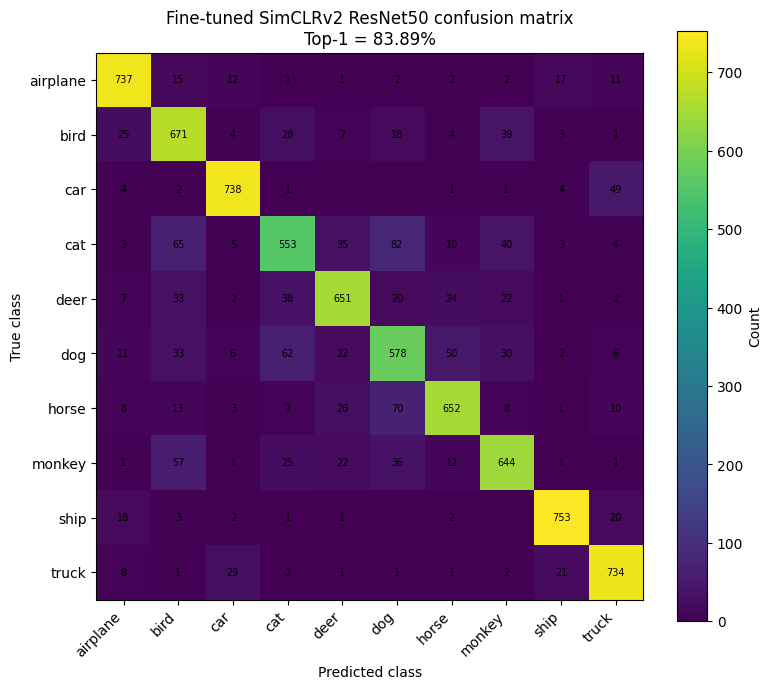

Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_confusion_matrix_normalized.png
Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_confusion_matrix_normalized.pdf


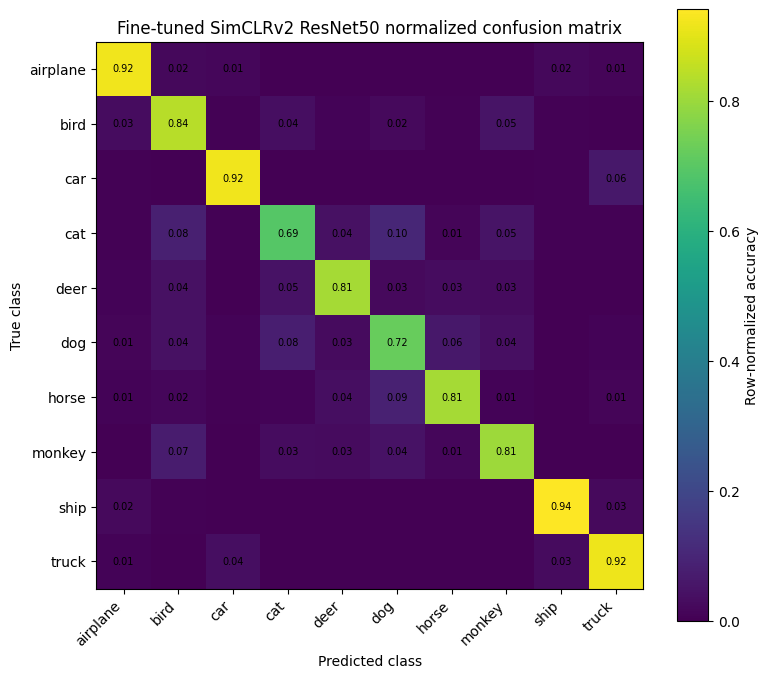

In [8]:
cm = confusion_matrix_np(res["y_true"], res["y_pred"], NUM_CLASSES)
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title(f"Fine-tuned SimCLRv2 ResNet50 confusion matrix\nTop-1 = {res['top1']:.2f}%")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), class_names)
plt.colorbar(label="Count")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm[i, j] > 0:
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=7)
savefig("finetune_fixed_confusion_matrix")
plt.show()

plt.figure(figsize=(8, 7))
plt.imshow(cm_norm)
plt.title("Fine-tuned SimCLRv2 ResNet50 normalized confusion matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), class_names)
plt.colorbar(label="Row-normalized accuracy")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        v = cm_norm[i, j]
        if v >= 0.01:
            plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
savefig("finetune_fixed_confusion_matrix_normalized")
plt.show()

## 8. Per-class accuracy figure

,class,correct,total,accuracy,accuracy_percent
0,ship,753,800,0.94125,94.125
1,car,738,800,0.92250,92.250
2,airplane,737,800,0.92125,92.125
3,truck,734,800,0.91750,91.750
4,bird,671,800,0.83875,83.875
5,horse,652,800,0.81500,81.500
6,deer,651,800,0.81375,81.375
7,monkey,644,800,0.80500,80.500
8,dog,578,800,0.72250,72.250
9,cat,553,800,0.69125,69.125


Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_per_class_accuracy.png
Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_per_class_accuracy.pdf


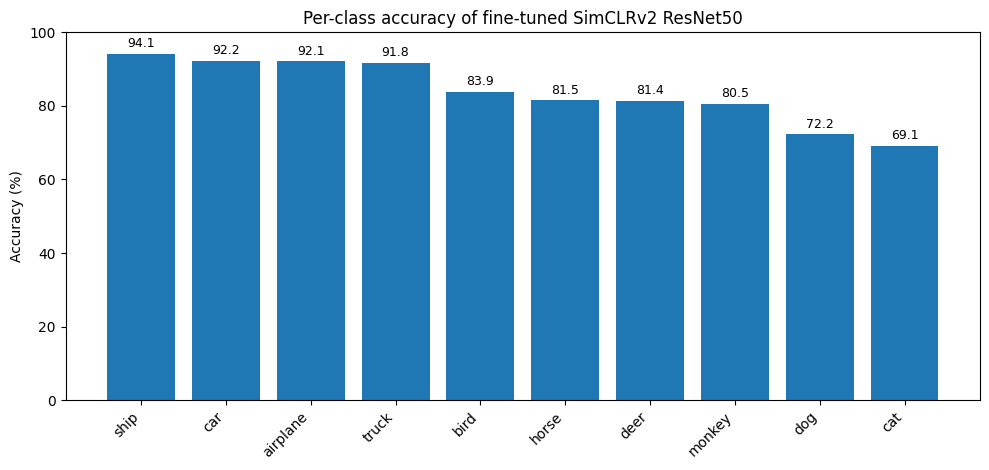

In [9]:
per_total = cm.sum(axis=1)
per_correct = np.diag(cm)
per_acc = per_correct / np.maximum(per_total, 1)

class_df = pd.DataFrame({
    "class": class_names,
    "correct": per_correct,
    "total": per_total,
    "accuracy": per_acc,
    "accuracy_percent": per_acc * 100.0,
}).sort_values("accuracy_percent", ascending=False).reset_index(drop=True)

display(class_df)
class_df.to_csv(TABLE_DIR / "finetune_fixed_per_class_accuracy.csv", index=False)

plt.figure(figsize=(10, 4.8))
plt.bar(class_df["class"], class_df["accuracy_percent"])
plt.title("Per-class accuracy of fine-tuned SimCLRv2 ResNet50")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")
for i, v in enumerate(class_df["accuracy_percent"]):
    plt.text(i, v + 1.0, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
savefig("finetune_fixed_per_class_accuracy")
plt.show()

## 9. Confidence analysis

Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_confidence_histogram.png
Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_confidence_histogram.pdf


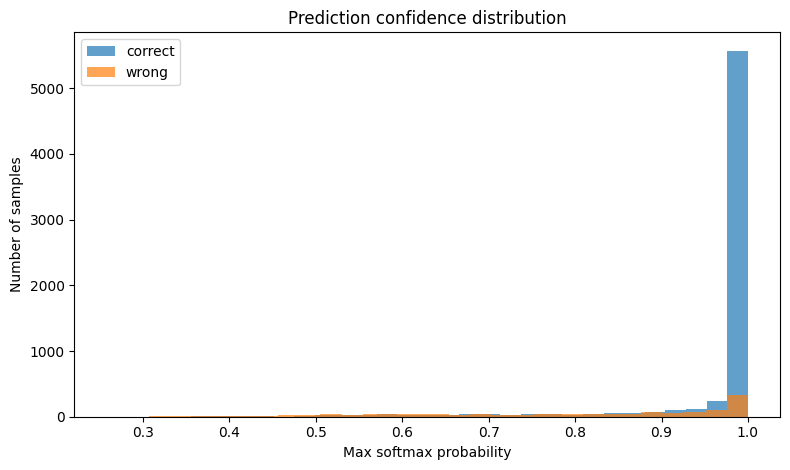

,class,mean_confidence,mean_confidence_correct,mean_confidence_wrong,error_rate_percent
0,cat,0.905633,0.947832,0.811153,30.875
1,dog,0.891137,0.929100,0.792296,27.750
2,monkey,0.908828,0.944443,0.761802,19.500
3,deer,0.937811,0.967916,0.806279,18.625
4,horse,0.933737,0.968497,0.780606,18.500
5,bird,0.938746,0.965071,0.801813,16.125
6,truck,0.958956,0.973255,0.799935,8.250
7,airplane,0.971484,0.983059,0.836083,7.875
8,car,0.970302,0.984002,0.807231,7.750
9,ship,0.969420,0.978843,0.818449,5.875


Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_error_rate_by_class.png
Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_error_rate_by_class.pdf


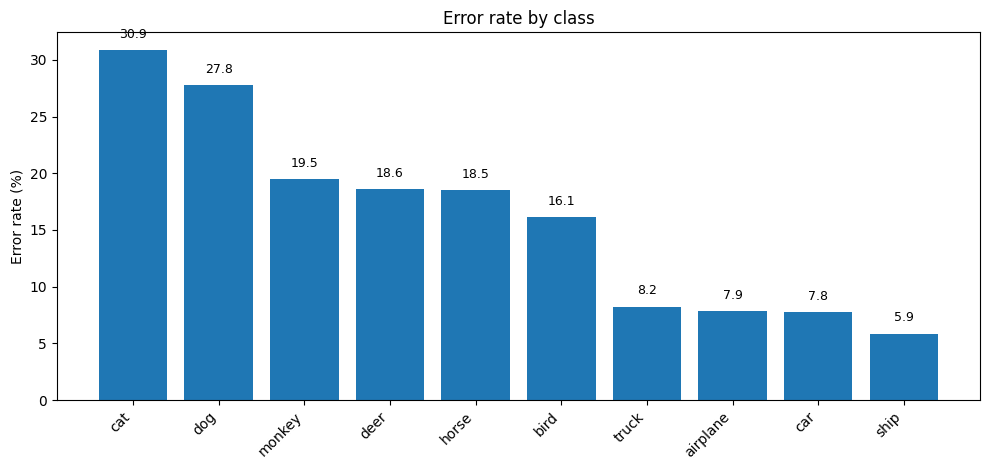

In [10]:
probs = res["y_prob"]
conf = probs.max(axis=1)
correct_mask = res["y_true"] == res["y_pred"]

plt.figure(figsize=(8, 4.8))
plt.hist(conf[correct_mask], bins=30, alpha=0.7, label="correct")
plt.hist(conf[~correct_mask], bins=30, alpha=0.7, label="wrong")
plt.title("Prediction confidence distribution")
plt.xlabel("Max softmax probability")
plt.ylabel("Number of samples")
plt.legend()
savefig("finetune_fixed_confidence_histogram")
plt.show()

conf_rows = []
for idx, name in enumerate(class_names):
    mask = res["y_true"] == idx
    if mask.sum() == 0:
        continue
    conf_rows.append({
        "class": name,
        "mean_confidence": float(conf[mask].mean()),
        "mean_confidence_correct": float(conf[mask & correct_mask].mean()) if np.any(mask & correct_mask) else np.nan,
        "mean_confidence_wrong": float(conf[mask & ~correct_mask].mean()) if np.any(mask & ~correct_mask) else np.nan,
        "error_rate_percent": 100.0 * float((~correct_mask[mask]).mean()),
    })

conf_df = pd.DataFrame(conf_rows).sort_values("error_rate_percent", ascending=False).reset_index(drop=True)
display(conf_df)
conf_df.to_csv(TABLE_DIR / "finetune_fixed_confidence_by_class.csv", index=False)

plt.figure(figsize=(10, 4.8))
plt.bar(conf_df["class"], conf_df["error_rate_percent"])
plt.title("Error rate by class")
plt.ylabel("Error rate (%)")
plt.xticks(rotation=45, ha="right")
for i, v in enumerate(conf_df["error_rate_percent"]):
    plt.text(i, v + 0.8, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
savefig("finetune_fixed_error_rate_by_class")
plt.show()

## 10. Optional learning curves from history/logs

Checkpoint tốt nhất thường không chứa toàn bộ training history. Cell này sẽ tự tìm CSV/log trong project. Nếu không có history/log thì sẽ bỏ qua, còn các hình ở trên vẫn chạy bình thường.

History CSV candidates: ['d:\\ML3\\paper_outputs\\finetune\\tables\\finetune_all_history.csv', 'd:\\ML3\\paper_outputs\\finetune\\tables\\ft0_lr002_history.csv', 'd:\\ML3\\paper_outputs\\linear_eval_memorysafe\\tables\\linear_eval_history.csv']
Using history CSV: d:\ML3\paper_outputs\finetune\tables\finetune_all_history.csv


,experiment,epoch,train_loss,train_top1,train_top5,val_loss,val_top1,val_top5,lr,time_sec,include_proj_layers,weight_decay
115,ft0_lr002,116,0.074357,97.62,99.98,0.756147,82.525,98.8250,0.000086,10.410970,0,0.0
116,ft0_lr002,117,0.069920,97.90,99.98,0.749373,82.600,98.9125,0.000055,10.495359,0,0.0
117,ft0_lr002,118,0.072137,97.66,99.98,0.745637,82.475,98.8250,0.000031,10.466176,0,0.0
118,ft0_lr002,119,0.058831,98.04,99.94,0.750339,82.525,98.8500,0.000014,10.547115,0,0.0
119,ft0_lr002,120,0.070890,97.66,99.92,0.762570,82.350,98.8750,0.000003,10.620266,0,0.0


Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_loss_curves.png
Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_loss_curves.pdf


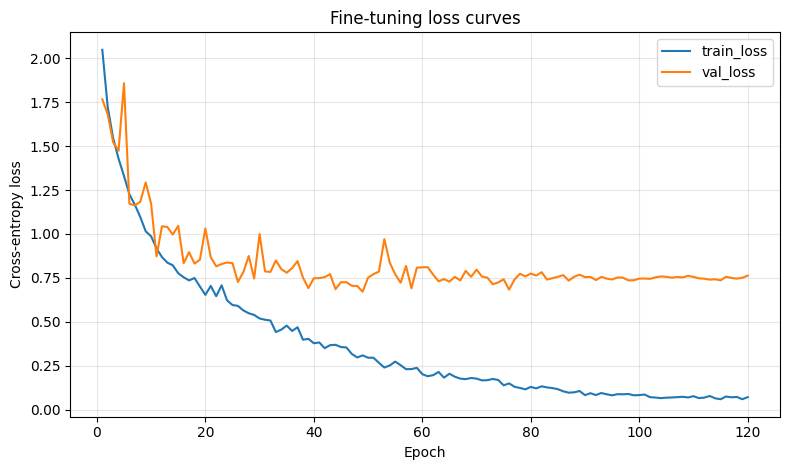

Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_accuracy_curves.png
Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_accuracy_curves.pdf


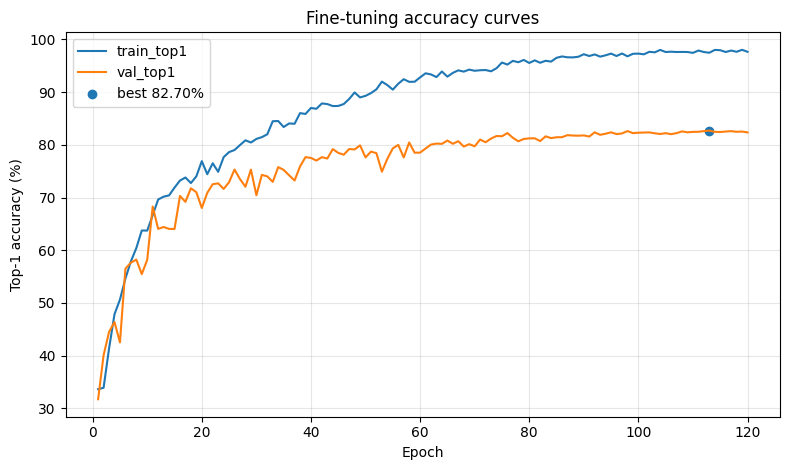

In [11]:
def normalize_history_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename = {}
    if "val_acc" in df.columns and "val_top1" not in df.columns:
        rename["val_acc"] = "val_top1"
    if "train_acc" in df.columns and "train_top1" not in df.columns:
        rename["train_acc"] = "train_top1"
    df = df.rename(columns=rename)
    for col in ["train_top1", "val_top1"]:
        if col in df.columns and df[col].max(skipna=True) <= 1.5:
            df[col] = df[col] * 100.0
    return df


def find_history_csv(project_dir: Path, ckpt_dir: Path):
    roots = [ckpt_dir, ckpt_dir.parent, project_dir / "paper_outputs" / "finetune", project_dir / "paper_outputs"]
    candidates = []
    for root in roots:
        if root.exists():
            candidates.extend(root.rglob("*history*.csv"))
            candidates.extend(root.rglob("*metrics*.csv"))
    seen, out = set(), []
    for p in candidates:
        if p not in seen:
            seen.add(p)
            out.append(p)
    return out


def parse_logs(log_dir: Path):
    rows = []
    if not log_dir.exists():
        return pd.DataFrame()
    pat = re.compile(
        r"epoch\s+(\d+)/(\d+).*?train_loss=([0-9.]+).*?train_acc=([0-9.]+)%.*?val_loss=([0-9.]+).*?val_acc=([0-9.]+)%",
        flags=re.IGNORECASE,
    )
    for p in sorted(log_dir.rglob("*.log")):
        for line in p.read_text(errors="ignore").splitlines():
            m = pat.search(line)
            if m:
                rows.append({
                    "source": str(p),
                    "epoch": int(m.group(1)),
                    "max_epoch": int(m.group(2)),
                    "train_loss": float(m.group(3)),
                    "train_top1": float(m.group(4)),
                    "val_loss": float(m.group(5)),
                    "val_top1": float(m.group(6)),
                })
    return pd.DataFrame(rows)

history = None
history_sources = find_history_csv(PROJECT_DIR, CKPT_DIR)
print("History CSV candidates:", [str(p) for p in history_sources[:5]])

for p in history_sources:
    try:
        df = pd.read_csv(p)
        if {"epoch", "train_loss"}.issubset(df.columns) or {"epoch", "val_top1"}.issubset(df.columns):
            history = normalize_history_df(df)
            print("Using history CSV:", p)
            break
    except Exception as e:
        print("Skip", p, repr(e))

if history is None:
    history = normalize_history_df(parse_logs(PROJECT_DIR / "logs"))
    if len(history):
        print("Using parsed logs")

if history is None or len(history) == 0:
    print("No train/val history found. Skipping learning-curve plots.")
else:
    display(history.tail())
    history.to_csv(TABLE_DIR / "finetune_fixed_history_used.csv", index=False)

    if "train_loss" in history.columns or "val_loss" in history.columns:
        plt.figure(figsize=(8, 4.8))
        if "train_loss" in history.columns:
            plt.plot(history["epoch"], history["train_loss"], label="train_loss")
        if "val_loss" in history.columns:
            plt.plot(history["epoch"], history["val_loss"], label="val_loss")
        plt.title("Fine-tuning loss curves")
        plt.xlabel("Epoch")
        plt.ylabel("Cross-entropy loss")
        plt.grid(True, alpha=0.3)
        plt.legend()
        savefig("finetune_fixed_loss_curves")
        plt.show()

    if "train_top1" in history.columns or "val_top1" in history.columns:
        plt.figure(figsize=(8, 4.8))
        if "train_top1" in history.columns:
            plt.plot(history["epoch"], history["train_top1"], label="train_top1")
        if "val_top1" in history.columns:
            plt.plot(history["epoch"], history["val_top1"], label="val_top1")
            best_i = history["val_top1"].idxmax()
            best_row = history.loc[best_i]
            plt.scatter([best_row["epoch"]], [best_row["val_top1"]], label=f"best {best_row['val_top1']:.2f}%")
        plt.title("Fine-tuning accuracy curves")
        plt.xlabel("Epoch")
        plt.ylabel("Top-1 accuracy (%)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        savefig("finetune_fixed_accuracy_curves")
        plt.show()

## 11. Paper-ready summary and comparison bar

,method,checkpoint,checkpoint_name,arch,dataset,image_size,num_classes,finetune_proj_layers,epoch_in_ckpt,best_acc_in_ckpt,eval_val_loss,eval_top1_percent,eval_top5_percent,correct,total
0,SimCLRv2 ResNet50 fine-tune fixed eval,d:\ML3\checkpoints_finetune_2\finetune_resnet5...,finetune_resnet50_best.pt,resnet50,stl10,96,10,1,115,83.8875,0.73267,83.8875,98.7625,6711,8000


Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_comparison_bar.png
Saved: d:\ML3\paper_outputs\finetune_fixed_eval\figures\finetune_fixed_comparison_bar.pdf


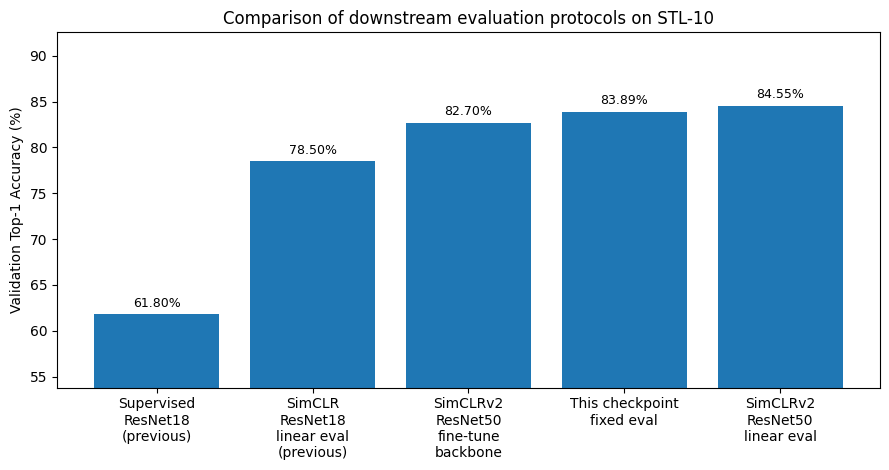

All outputs saved to: d:\ML3\paper_outputs\finetune_fixed_eval
Figures: d:\ML3\paper_outputs\finetune_fixed_eval\figures
Tables: d:\ML3\paper_outputs\finetune_fixed_eval\tables


In [12]:
summary = pd.DataFrame([{
    "method": "SimCLRv2 ResNet50 fine-tune fixed eval",
    "checkpoint": str(CKPT_PATH),
    "checkpoint_name": Path(CKPT_PATH).name,
    "arch": ARCH,
    "dataset": LABELED_DATASET,
    "image_size": IMAGE_SIZE,
    "num_classes": NUM_CLASSES,
    "finetune_proj_layers": FINETUNE_PROJ_LAYERS,
    "epoch_in_ckpt": ckpt.get("epoch"),
    "best_acc_in_ckpt": ckpt.get("best_acc"),
    "eval_val_loss": res["loss"],
    "eval_top1_percent": res["top1"],
    "eval_top5_percent": res["top5"],
    "correct": res["correct"],
    "total": res["total"],
}])
summary.to_csv(TABLE_DIR / "finetune_fixed_eval_summary.csv", index=False)
display(summary)

pred_df = pd.DataFrame({
    "y_true": res["y_true"],
    "y_pred": res["y_pred"],
    "true_class": [class_names[i] for i in res["y_true"]],
    "pred_class": [class_names[i] for i in res["y_pred"]],
    "confidence": conf,
    "correct": correct_mask,
})
pred_df.to_csv(TABLE_DIR / "finetune_fixed_predictions.csv", index=False)

comparison = pd.DataFrame([
    {"method": "Supervised\nResNet18\n(previous)", "top1": 61.80},
    {"method": "SimCLR\nResNet18\nlinear eval\n(previous)", "top1": 78.50},
    {"method": "SimCLRv2\nResNet50\nfine-tune\nbackbone", "top1": 82.70},
    {"method": "This checkpoint\nfixed eval", "top1": res["top1"]},
    {"method": "SimCLRv2\nResNet50\nlinear eval", "top1": 84.55},
])
comparison.to_csv(TABLE_DIR / "finetune_fixed_comparison.csv", index=False)

plt.figure(figsize=(9, 4.8))
plt.bar(comparison["method"], comparison["top1"])
plt.title("Comparison of downstream evaluation protocols on STL-10")
plt.ylabel("Validation Top-1 Accuracy (%)")
plt.ylim(max(0, comparison["top1"].min() - 8), min(100, comparison["top1"].max() + 8))
plt.xticks(rotation=0, ha="center")
for i, v in enumerate(comparison["top1"]):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)
savefig("finetune_fixed_comparison_bar")
plt.show()

print("All outputs saved to:", OUT_ROOT)
print("Figures:", FIG_DIR)
print("Tables:", TABLE_DIR)